<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%5B%E1%84%89%E1%85%B3%E1%84%91%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%90%E1%85%B3%E1%84%86%E1%85%B5%E1%84%89%E1%85%A7%E1%86%AB%5D6_%E1%84%80%E1%85%A5%E1%86%AB%E1%84%80%E1%85%A1%E1%86%BC%E1%84%83%E1%85%A6%E1%84%8B%E1%85%B5%E1%84%90%E1%85%A5_EDA_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8%E1%84%8B%E1%85%A8%E1%84%8C%E1%85%A6(%E1%84%86%E1%85%AE%E1%86%AB%E1%84%8C%E1%85%A6)_3%E1%84%90%E1%85%B5%E1%86%B7_%E1%84%80%E1%85%B5%E1%86%B7%E1%84%89%E1%85%A9%E1%84%8B%E1%85%A7%E1%86%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[Mission] 기초 통계와 데이터 시각화**  
**┗ 건강검진 데이터 시각화하기**
---
> **목차(Context)**

* 데이터 살펴보기
* EDA

In [ ]:
# ## 개발환경 세팅하기

# # ▶ 한글 폰트 다운로드
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [ ]:
# # ▶ 한글 폰트 설정하기
# import matplotlib.pyplot as plt
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] =False

# # ▶ Warnings 제거
# import warnings
# warnings.filterwarnings('ignore')

# # ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
# from google.colab import drive
# drive.mount('/content/drive')


## **데이터 준비하기**
---

> **데이터 준비하기**

- 데이터 출처 : [공공데이터 포털](https://www.data.go.kr/data/15007122/fileData.do#/layer_data_infomation) `국민건강보험공단_건강검진정보`

- 데이터 명세  

| No. | 표준항목명          | 영문명            | 설명                                                                                                           | 표현형식/단위          | 예시         |
|-----|-----------------|------------------|---------------------------------------------------------------------------------------------------------------|---------------------|--------------|
| 1   | 기준년도          | HCHK_YEAR        | 해당 정보의 기준년도를 제공함                                                                                  | YYYY                | 2009         |
| 2   | 가입자일련번호       | IDV_ID           | 해당가입자에 부여한 일련번호                                                                                  | 1 ~ 1,000,000       | 1            |
| 3   | 시도코드          | SIDO             | 해당 수진자 거주지의 시도코드                                                                                  | -                   | 26           |
| 4   | 성별              | SEX              | 해당 정보 대상자의 성별을 제공함                                                                               | 성별 : 1(남자), 2(여자) | 1            |
| 5   | 연령대코드(5세단위)    | AGE_GROUP        | 기준년도에 수진자의 나이를 5세 단위로 그룹화하여 구분한 코드                                                     | 5세 단위 그룹화, 85세 이상은 85+로 그룹화 | -            |
| 6   | 신장(5cm단위)     | HEIGHT           | 검진자의 키(5CM 단위)                                                                                          | N/Cm                | 140          |
| 7   | 체중(5kg단위)     | WEIGHT           | 검진자의 몸무게(5KG 단위)                                                                                      | N/Kg                | 45           |
| 8   | 허리둘레          | WAIST            | 검진자의 허리둘레                                                                                              | N/Cm                | 82           |
| 9   | 시력(좌)          | SIGHT_LEFT       | 수검자의 좌측 눈의 시력                                                                                        | N                   | 0.5          |
| 10  | 시력(우)          | SIGHT_RIGHT      | 수검자의 우측 눈의 시력                                                                                        | N                   | 0.5          |
| 11  | 청력(좌)          | HEAR_LEFT        | 수검자의 좌측 귀의 청력                                                                                        | N                   | 1            |
| 12  | 청력(우)          | HEAR_RIGHT       | 수검자의 우측 귀의 청력                                                                                        | N                   | 1            |
| 13  | 수축기혈압         | BP_HIGH          | 검진자의 최고 혈압으로 심장이 수축해서 강한 힘으로 혈액을 동맥에 보낼 때의 혈관 내압                                   | N/mmHg              | 140          |
| 14  | 이완기혈압         | BP_LWST          | 검진자의 최저 혈압으로 심장의 완기시의 혈압                                                                      | N/mmHg              | 81           |
| 15  | 식전혈당(공복혈당)    | BLDS             | 검진자 식사 전 혈당(혈액 100ml당 함유 되어 있는 포도당의 농도) 수치                                               | N/mg/dL             | 94           |
| 16  | 총콜레스테롤        | TOT_CHOLE        | 혈청 중의 에스텔형, 비에스테형(유리)콜레스테롤의 합                                                               | N/mg/dL             | 164          |
| 17  | 트리글리세라이드    | TRIGLYCERIDE     | 단순지질 혹은 중성지질을 뜻함                                                                                    | N/mg/dL             | 94           |
| 18  | HDL콜레스테롤      | HDL_CHOLE        | HDL(고밀도 리포단백질)에 포함되는 콜레스테롤                                                                      | N/mg/dL             | 45           |
| 19  | LDL콜레스테롤      | LDL_CHOLE        | LDL(저밀도 리포단백질)에 함유된 콜레스테롤                                                                        | N/mg/dL             | 150, 130     |
| 20  | 혈색소            | HMG              | 혈액이나 혈구 속에 존재하는 색소단백으로 글로빈(globin)과 엠(heme)으로 구성되며 혈중의 산소운반체로서의 역할 수행       | N/g/dL              | 15.3984375   |
| 21  | 요단백            | OLIG_PROTE_CD    | 소변에 단백질이 섞여 나오는 것                                                                                  | N                   | 1            |
| 22  | 혈청크레아티닌       | CREATININE       | 크레아틴의 탈수물로 내인성 단백대사의 종말산물로서 신장에서 배설되고 그 증감은 음식물에 관계없이 근육의 발육과 운동에 관계함 | N/mg/dL             | 0.8          |
| 23  | 혈청지오티(AST)    | AST              | 간 기능을 나타내는 혈액검사상의 수치, 간세포 이외에 심장, 신장, 뇌, 근육 등에도 존재하는 효소로 이러한 세포들이 손상을 받는 경우 농도가 증가함 | N/IU/L              | 12           |
| 24  | 혈청지피티(ALT)    | ALT              | 간 기능을 나타내는 혈액검사상의 수치, ALT는 주로 간세포 안에 존재하는 효소로, 간세포가 손상을 받는 경우 농도가 증가함        | N/U/L               | 15           |
| 25  | 감마지티피         | GAMMA_GTP        | 간 기능을 나타내는 혈액검사상의 수치, 간 내의 쓸개관(담관)에 존재하는 효소로 글루타민산을 외부에 펩티드나 아미노산 등으로 옮기는 작용을 함 | N/U/L               | 119, 114     |
| 26  | 흡연상태           | SMK_STAT_TYPE_CD | 해당 수검자의 흡연 상태 여부                                                                                    | N                   | 1            |
| 27  | 음주여부           | DRK_YN           | 해당 수검자의 음주 상태 여부                                                                                    | N/Y                 | 1            |
| 28  | 구강검진수검여부     | HCHK_OE_INSPEC_YN | 해당 검진자가 구강검진을 선택하여 검진하였는지 여부에 대한 항목                                                   | N/Y                 | 1            |
| 29  | 치아우식증유무       | CRS_YN           | 해당 수검자의 치아우식증 유무                                                                                   | N                   | 1            |
| 30  | 치석              | TTR_YN           | 해당 수검자의 치석 여부                                                                                         | N/Y                 | 1            |

     


In [ ]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Pandas 보기 옵션
pd.set_option('display.max_columns', 100)

### 문제1. 데이터 불러오기
: 제공된 `./국민건강보험공단_건강검진정보_20221231.CSV` 파일을 불러오세요. 한글 폰트가 깨질 경우, 인코딩을 확인해보세요.

In [ ]:
df = pd.read_csv('국민건강보험공단_건강검진정보_2023.csv', encoding='euc-kr')

## **EDA : Data 살펴보기**  
---

* 수집된 데이터의 기본 정보들을 확인  

  (1) Data shape(형태) 확인

  (2) Data type 확인

  (3) Null값 확인 (※ 빈 값의 Data)

  (4) Outlier 확인 (※ 정상적인 범주를 벗어난 Data)  

### 전체적인 데이터 살펴보기

#### 문제2. 데이터의 형태를 확인해보세요.
- 몇 개의 데이터가 존재하나요?
- 몇 개의 특성이 존재하나요?

In [ ]:
# Data 형태 확인
df.shape

(1000000, 33)

#### 문제3. 데이터의 타입을 확인해보세요.
- 어떤 특성들이 데이터에 포함되어 있나요?
- 각 특성의 값은 어떤 데이터 타입으로 구성되어 있나요?

In [ ]:
# Data type 확인
df.dtypes

기준년도               int64
가입자일련번호            int64
시도코드               int64
성별코드               int64
연령대코드(5세단위)        int64
신장(5cm단위)          int64
체중(5kg단위)          int64
허리둘레             float64
시력(좌)            float64
시력(우)            float64
청력(좌)            float64
청력(우)            float64
수축기혈압            float64
이완기혈압            float64
식전혈당(공복혈당)       float64
총콜레스테롤           float64
트리글리세라이드         float64
HDL콜레스테롤         float64
LDL콜레스테롤         float64
혈색소              float64
요단백              float64
혈청크레아티닌          float64
혈청지오티(AST)       float64
혈청지피티(ALT)       float64
감마지티피            float64
흡연상태             float64
음주여부             float64
구강검진수검여부           int64
치아우식증유무          float64
결손치 유무           float64
치아마모증유무          float64
제3대구치(사랑니) 이상    float64
치석               float64
dtype: object

In [ ]:
# 데이터 값 확인 - 상위 30행을 출력하여 데이터를 확인해보세요.
df.head(30)

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2023,34735,46,2,9,155,70,92.0,1.2,1.2,1.0,1.0,139.0,89.0,98.0,168.0,181.0,46.0,86.0,13.8,1.0,0.5,26.0,24.0,50.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
1,2023,4105118,11,1,17,160,55,86.0,0.9,9.9,1.0,2.0,123.0,52.0,87.0,NaN,NaN,NaN,NaN,15.5,1.0,1.3,22.0,11.0,31.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
2,2023,362482,36,2,13,150,65,96.0,1.0,0.8,1.0,1.0,109.0,69.0,114.0,220.0,307.0,52.0,107.0,13.5,1.0,1.1,22.0,29.0,24.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
3,2023,653166,11,1,13,160,70,85.0,1.0,1.2,1.0,1.0,116.0,64.0,98.0,91.0,171.0,45.0,11.0,15.6,1.0,0.9,22.0,21.0,27.0,3.0,1.0,1,0.0,NaN,NaN,NaN,0.0
4,2023,4152237,41,1,12,165,65,84.5,1.0,1.2,1.0,1.0,137.0,86.0,105.0,NaN,NaN,NaN,NaN,14.9,1.0,0.8,23.0,33.0,49.0,3.0,1.0,0,NaN,NaN,NaN,NaN,NaN
5,2023,3587054,26,2,5,170,50,69.2,1.0,1.2,1.0,1.0,92.0,60.0,93.0,NaN,NaN,NaN,NaN,12.2,1.0,0.6,16.0,11.0,12.0,1.0,1.0,1,1.0,NaN,NaN,NaN,1.0
6,2023,4045005,30,1,7,180,70,80.5,1.5,1.5,1.0,1.0,120.0,60.0,85.0,NaN,NaN,NaN,NaN,14.7,1.0,0.9,15.0,15.0,20.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
7,2023,1021257,11,1,6,170,75,91.0,0.9,0.8,1.0,1.0,120.0,69.0,92.0,NaN,NaN,NaN,NaN,14.9,1.0,0.7,31.0,48.0,16.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
8,2023,1073372,44,1,13,165,70,91.0,1.5,1.2,1.0,1.0,127.0,79.0,110.0,NaN,NaN,NaN,NaN,16.3,1.0,1.0,24.0,33.0,34.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN
9,2023,722514,49,1,10,165,80,89.0,1.2,1.2,1.0,1.0,146.0,85.0,74.0,194.0,59.0,55.0,127.0,16.5,1.0,0.7,53.0,69.0,53.0,2.0,1.0,0,NaN,NaN,NaN,NaN,NaN


#### 문제4 : 결측치 확인하기
- 각 특성 별로 결측치 개수와 비율을 확인해보세요.
- 결측치의 양상이 특성마다 차이가 난다면, 왜 그런 차이가 발생했을까요?

In [ ]:
# 각 열에 있는 결측치의 수와 결측치의 비율을 계산해보세요.
df.isna().sum()

기준년도                   0
가입자일련번호                0
시도코드                   0
성별코드                   0
연령대코드(5세단위)            0
신장(5cm단위)              0
체중(5kg단위)              0
허리둘레                 411
시력(좌)                184
시력(우)                177
청력(좌)                137
청력(우)                138
수축기혈압               5747
이완기혈압               5747
식전혈당(공복혈당)          5814
총콜레스테롤            661394
트리글리세라이드          661394
HDL콜레스테롤          661394
LDL콜레스테롤          667247
혈색소                 5817
요단백                11156
혈청크레아티닌             5814
혈청지오티(AST)          5816
혈청지피티(ALT)          5816
감마지티피               5813
흡연상태                  89
음주여부                  56
구강검진수검여부               0
치아우식증유무           653152
결손치 유무           1000000
치아마모증유무          1000000
제3대구치(사랑니) 이상    1000000
치석                653152
dtype: int64

In [ ]:
df.isna().mean() * 100

기준년도               0.0000
가입자일련번호            0.0000
시도코드               0.0000
성별코드               0.0000
연령대코드(5세단위)        0.0000
신장(5cm단위)          0.0000
체중(5kg단위)          0.0000
허리둘레               0.0411
시력(좌)              0.0184
시력(우)              0.0177
청력(좌)              0.0137
청력(우)              0.0138
수축기혈압              0.5747
이완기혈압              0.5747
식전혈당(공복혈당)         0.5814
총콜레스테롤            66.1394
트리글리세라이드          66.1394
HDL콜레스테롤          66.1394
LDL콜레스테롤          66.7247
혈색소                0.5817
요단백                1.1156
혈청크레아티닌            0.5814
혈청지오티(AST)         0.5816
혈청지피티(ALT)         0.5816
감마지티피              0.5813
흡연상태               0.0089
음주여부               0.0056
구강검진수검여부           0.0000
치아우식증유무           65.3152
결손치 유무           100.0000
치아마모증유무          100.0000
제3대구치(사랑니) 이상    100.0000
치석                65.3152
dtype: float64

#### 문제5 : 결측치 시각화하기
- 데이터프레임에서 결측치가 존재하는 부분을 시각화해보세요.
- 결측치가 있는 부분을 적절한 방법으로 제거해보세요.
- 동일한 방법으로 시각화를 다시 진행하여 정말 제거가 되었는지 시각적으로 확인해봅시다.
- 한글이 깨지는 경우 아래 코드를 실행해주세요.

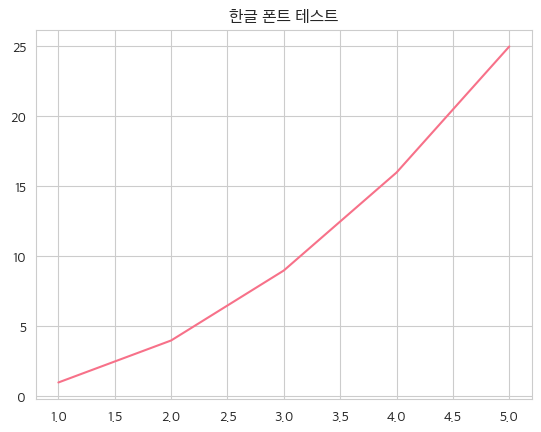

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 폰트 파일 경로 지정
font_path = '/System/Library/Fonts/AppleSDGothicNeo.ttc'

# 폰트 프로퍼티 생성
font_prop = font_manager.FontProperties(fname=font_path)

# matplotlib에 폰트 설정 적용
plt.rcParams['font.family'] = font_prop.get_name()

# 그래프 예시
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
plt.plot(x, y)
plt.title('한글 폰트 테스트')
plt.show()


In [ ]:
# 기본 그래프 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 처리
sns.set_palette("husl", 8)
sns.set_style("whitegrid")

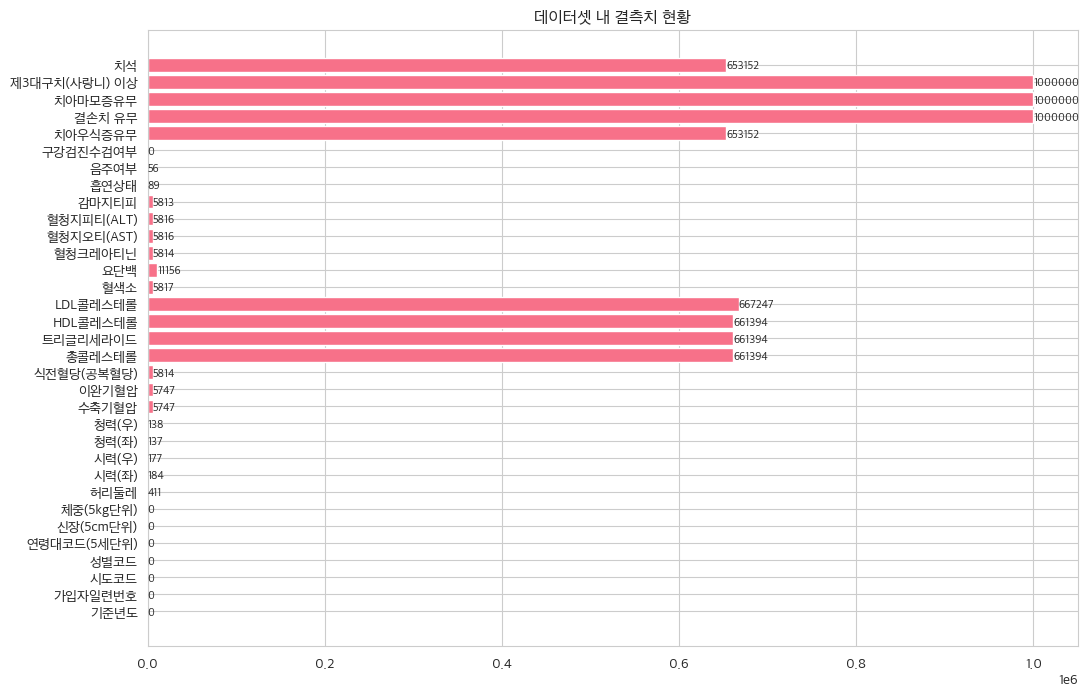

In [ ]:
# 결측치가 존재하는 부분을 시각화 해보세요.
#결측치 확인
null_count = df.isna().sum()
plt.rcParams['font.family'] = font_prop.get_name()
# 결측치 시각화
plt.figure(figsize=(12, 8))
plt.barh(df.columns, null_count)
plt.title('데이터셋 내 결측치 현황')

# 결측치 수
for index, value in enumerate(null_count):
    plt.text(value, index, str(value), va='center', ha='left', fontsize=8)

plt.show()

In [ ]:
# 어떤 데이터에서 결측치가 관측되었나요? 해당 데이터는 어떻게 전처리하는 게 좋을까요?

# 결측치가 많은 열 제거
df = df.drop(columns=['치아우식증유무','결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상','치석', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤','요단백'])

# 결측치가 포함된 모든 행 제거
df = df.dropna()

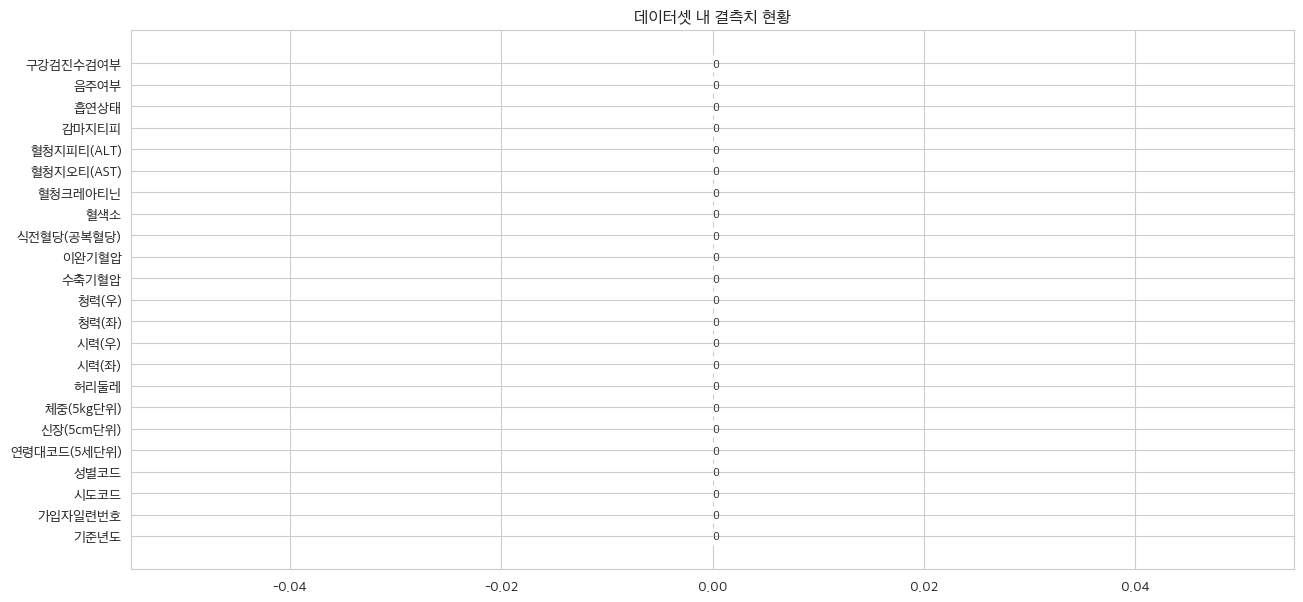

In [ ]:
# 전처리 이후 전과 후가 어떻게 달라졌는지 확인해봅시다.
#결측치 확인
null_count = df.isna().sum()
plt.rcParams['font.family'] = font_prop.get_name()

# 결측치 시각화
plt.figure(figsize=(12, 8))
plt.barh(df.columns, null_count)
plt.title('데이터셋 내 결측치 현황')

# 결측치 수
for index, value in enumerate(null_count):
    plt.text(value, index, str(value), va='center', ha='left', fontsize=8)
plt.show()

#### 문제6 : 중복값 확인하기
- 데이터에 중복값이 있는 지 확인해보세요. 만약 있다면, 제거하세요.

In [ ]:
df_duplicated_count = df.duplicated().sum()
print(f"중복값 개수:{df_duplicated_count}")

# 중복값 제거
df = df.drop_duplicates()
print("중복값 제거 완료")

중복값 개수:0
중복값 제거 완료


#### 문제7 : 실제값 매핑하여 컬럼 수정하기
- 현재 데이터는 연령대를 코드로 제공하고 있습니다. 연령대 코드가 의미하는 바는 다음 표와 같습니다.
- `연령대`라는 새로운 열을 만들고, 연령대 코드를 의미하는 연령대로 매핑해보세요.

In [ ]:
# 연령대 코드 매핑
age_group_mapping = {
    1: "0-4", 2: "5-9", 3: "10-14", 4: "15-19", 5: "20-24",
    6: "25-29", 7: "30-34", 8: "35-39", 9: "40-44", 10: "45-49",
    11: "50-54", 12: "55-59", 13: "60-64", 14: "65-69", 15: "70-74",
    16: "75-79", 17: "80-84", 18: "85+"
}

In [ ]:
# 연령대 코드를 새로운 매핑으로 업데이트 해보세요
df["연령대"] = df["연령대코드(5세단위)"].replace(age_group_mapping)

- 시도코드도 유사한 방식으로 맵핑해보세요. `시도`로 새로운 컬럼을 생성하시면 됩니다.
- 시도코드에 대한 힌트는 [행정표준코드관리시스템](https://www.code.go.kr/stdcode/regCodeL.do)에서 얻으실 수 있습니다.

In [ ]:
# 시도 코드 매핑
region_group_mapping = {
    11: "서울특별시",
    26: "부산광역시",
    27: "대구광역시",
    28: "인천광역시",
    29: "광주광역시",
    30: "대전광역시",
    31: "울산광역시",
    36: "세종특별자치시",
    41: "경기도",
    42: "강원도",
    43: "충청북도",
    44: "충청남도",
    45: "전라북도",
    46: "전라남도",
    47: "경상북도",
    48: "경상남도",
    49: "제주특별자치도"  # 폐지인데 데이터가 있음
    # 50: "제주특별자치도"  # 현행인데 데이터가 없음
}

In [ ]:
np.sort(df["시도코드"].unique())

array([11, 26, 27, 28, 29, 30, 31, 36, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [ ]:
# 시도 코드를 새로운 매핑으로 업데이트 해보세요
df["시도"] = df["시도코드"].replace(region_group_mapping)

In [ ]:
df["시도"].unique()

array(['전라남도', '서울특별시', '세종특별자치시', '경기도', '부산광역시', '대전광역시', '충청남도',
       '제주특별자치도', '인천광역시', '광주광역시', '경상남도', '경상북도', '강원도', '울산광역시',
       '전라북도', '충청북도', '대구광역시'], dtype=object)

- 나머지 컬럼들은 건강보험공단에서 제공하는 코드북 바탕으로 매핑해보겠습니다.

In [ ]:
# 성별에 대한 매핑 작업
gender = {
    1 : '남자',
    2 : '여자'
}
df['성별'] = df['성별코드'].map(gender)

In [ ]:
# 흡연상태에 대한 매핑 작업
smoking = {
    1 : '피우지 않는다',
    2 : '이전에 피웠으나 끊었다',
    3 : '현재도 피우고 있다'
}
df['흡연상태'] = df['흡연상태'].map(smoking)

In [ ]:
# 음주 여부에 대한 매핑 작업
drinking = {
    0 : '마시지 않는다',
    1 : '마신다'
}
df['음주여부'] = df['음주여부'].map(drinking)

In [ ]:
# 구강검진수검여부에 대한 매핑 작업
teeth = {
    0 : '미수검',
    1 : '수검'
}
df['구강검진수검여부'] = df['구강검진수검여부'].map(teeth)

In [ ]:
df.head(3)

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),혈색소,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,연령대,시도,성별
0,2023,34735,46,2,9,155,70,92.0,1.2,1.2,1.0,1.0,139.0,89.0,98.0,13.8,0.5,26.0,24.0,50.0,피우지 않는다,마신다,미수검,40-44,전라남도,여자
1,2023,4105118,11,1,17,160,55,86.0,0.9,9.9,1.0,2.0,123.0,52.0,87.0,15.5,1.3,22.0,11.0,31.0,피우지 않는다,마신다,미수검,80-84,서울특별시,남자
2,2023,362482,36,2,13,150,65,96.0,1.0,0.8,1.0,1.0,109.0,69.0,114.0,13.5,1.1,22.0,29.0,24.0,피우지 않는다,마신다,미수검,60-64,세종특별자치시,여자


In [ ]:
df = df.drop(columns = ['시도코드'])
df = df.drop(columns = ['성별코드'])
df = df.drop(columns = ['연령대코드(5세단위)'])
df.head(3)

,기준년도,가입자일련번호,신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),혈색소,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,연령대,시도,성별
0,2023,34735,155,70,92.0,1.2,1.2,1.0,1.0,139.0,89.0,98.0,13.8,0.5,26.0,24.0,50.0,피우지 않는다,마신다,미수검,40-44,전라남도,여자
1,2023,4105118,160,55,86.0,0.9,9.9,1.0,2.0,123.0,52.0,87.0,15.5,1.3,22.0,11.0,31.0,피우지 않는다,마신다,미수검,80-84,서울특별시,남자
2,2023,362482,150,65,96.0,1.0,0.8,1.0,1.0,109.0,69.0,114.0,13.5,1.1,22.0,29.0,24.0,피우지 않는다,마신다,미수검,60-64,세종특별자치시,여자


#### 문제8 : 이상치 탐지하기
- 사분위수를 이용하여 이상치를 탐지해봅시다.
- 데이터프레임과 이상치 삭제 대상 컬럼을 패러미터로 받고, 각 컬럼 별 이상치를 삭제한 이후의 데이터 프레임을 반환하는 함수를 작성해보세요.

In [ ]:
# 이상치 탐지전 추가!
# 기준년도, 청력, 가입자일련번호는
# 범주형으로 타입 변경해야 할 듯

In [ ]:
print(df['기준년도'].unique())
print(df['청력(좌)'].unique())
print(df['청력(우)'].unique())
print(df['가입자일련번호'].unique())

[2023]
[1. 2. 3.]
[1. 2. 3.]
[  34735 4105118  362482 ... 3889375 2618086 1279122]


In [ ]:
# 오브젝트(str)로 변경
df['기준년도'] = df['기준년도'].astype(str)
df['청력(좌)'] = df['청력(좌)'].astype(str)
df['청력(우)'] = df['청력(우)'].astype(str)
df['가입자일련번호'] = df['가입자일련번호'].astype(str)

In [ ]:
# 이상치 탐지 및 삭제를 위해 기존 데이터 백업
new_df = df.copy()
new_df.shape

(993356, 23)

In [ ]:
# 각 열에 대해 이상치 데이터가 삭제된 새로운 데이터 프레임을 반환하는 함수 작성
def remove_out(dataframe, remove_col):
    for col in remove_col:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        dataframe = dataframe[(dataframe[col] >= lower) & (dataframe[col] <= upper)]
    return dataframe

# int,float 타입만 이상치 제거
cols = new_df.select_dtypes(include=[int,float]).columns

# 이상치 제거 실행
new2_df = remove_out(new_df, cols)

In [ ]:
# 함수 실행 및 이상치 제거 전/후 데이터프레임 크기 비교
new2_df.shape

(713363, 23)

### 개별 데이터 살펴보기

#### 문제9 : 수치형 데이터와 범주형 데이터 구분하기
- 수치형 데이터와 범주형 데이터는 데이터를 살펴보는데 차이가 있습니다. 수치형 데이터와 범주형 데이터를 구분하세요.

In [ ]:
# 전체 데이터
new2_df.dtypes

기준년도           object
가입자일련번호        object
신장(5cm단위)       int64
체중(5kg단위)       int64
허리둘레          float64
시력(좌)         float64
시력(우)         float64
청력(좌)          object
청력(우)          object
수축기혈압         float64
이완기혈압         float64
식전혈당(공복혈당)    float64
혈색소           float64
혈청크레아티닌       float64
혈청지오티(AST)    float64
혈청지피티(ALT)    float64
감마지티피         float64
흡연상태           object
음주여부           object
구강검진수검여부       object
연령대            object
시도             object
성별             object
dtype: object

In [ ]:
# 범주형 데이터
categorical_cols = new2_df.select_dtypes(include=['object']).columns
print("범주형 데이터:", categorical_cols)

범주형 데이터: Index(['기준년도', '가입자일련번호', '청력(좌)', '청력(우)', '흡연상태', '음주여부', '구강검진수검여부', '연령대',
       '시도', '성별'],
      dtype='object')


In [ ]:
# 수치형 데이터
numeric_cols = new2_df.select_dtypes(include=[int, float]).columns
print("수치형 데이터:", numeric_cols)

수치형 데이터: Index(['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '수축기혈압', '이완기혈압',
       '식전혈당(공복혈당)', '혈색소', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피'],
      dtype='object')


#### 문제10 : 기술통계량 확인하기
- 수치형 데이터와 범주형 데이터의 기술통계량을 확인해보세요.

In [ ]:
# 전체 기술 통계량
new2_df.describe(include='all')

,기준년도,가입자일련번호,신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),혈색소,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,연령대,시도,성별
count,713363,713363,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363,713363,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363,713363,713363,713363,713363,713363
unique,1,713363,NaN,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2,14,17,2
top,2023,34735,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,피우지 않는다,마신다,미수검,50-54,경기도,여자
freq,713363,1,NaN,NaN,NaN,NaN,NaN,691342,692264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,497800,460916,458080,88809,190658,396166
mean,NaN,NaN,161.977850,61.920908,79.122759,0.929345,0.927518,NaN,NaN,120.819872,73.968120,95.456013,14.020775,0.808782,22.758530,19.914177,21.985493,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,9.182596,12.232093,9.702530,0.319234,0.319442,NaN,NaN,13.280729,9.229891,11.110635,1.381412,0.190688,6.137575,8.315974,10.521784,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,135.000000,30.000000,53.000000,0.100000,0.100000,NaN,NaN,85.000000,51.000000,65.000000,10.000000,0.300000,4.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,155.000000,55.000000,72.000000,0.700000,0.700000,NaN,NaN,111.000000,68.000000,88.000000,13.000000,0.700000,18.000000,14.000000,14.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,160.000000,60.000000,79.000000,1.000000,1.000000,NaN,NaN,120.000000,74.000000,94.000000,14.000000,0.800000,22.000000,18.000000,19.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,170.000000,70.000000,86.000000,1.200000,1.200000,NaN,NaN,130.000000,80.000000,102.000000,15.000000,0.900000,26.000000,25.000000,27.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 수치형 변수의 기술 통계량
new2_df.select_dtypes(include=[int, float]).describe()

,신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),혈색소,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피
count,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000,713363.000000
mean,161.977850,61.920908,79.122759,0.929345,0.927518,120.819872,73.968120,95.456013,14.020775,0.808782,22.758530,19.914177,21.985493
std,9.182596,12.232093,9.702530,0.319234,0.319442,13.280729,9.229891,11.110635,1.381412,0.190688,6.137575,8.315974,10.521784
min,135.000000,30.000000,53.000000,0.100000,0.100000,85.000000,51.000000,65.000000,10.000000,0.300000,4.000000,1.000000,1.000000
25%,155.000000,55.000000,72.000000,0.700000,0.700000,111.000000,68.000000,88.000000,13.000000,0.700000,18.000000,14.000000,14.000000
50%,160.000000,60.000000,79.000000,1.000000,1.000000,120.000000,74.000000,94.000000,14.000000,0.800000,22.000000,18.000000,19.000000
75%,170.000000,70.000000,86.000000,1.200000,1.200000,130.000000,80.000000,102.000000,15.000000,0.900000,26.000000,25.000000,27.000000
max,190.000000,105.000000,109.000000,1.900000,1.900000,160.000000,99.000000,129.000000,18.300000,1.400000,44.000000,46.000000,55.000000


In [ ]:
# 각 변수들은 어떤 특징을 가지고 있나요?
# 연속된 수치들이다.
# 수치형 변수의 기술 통계는 개수, 평균, 표준편차, 최소값, 최대값, 사분위수를 확인할 수 있다.

In [ ]:
# 범주형 변수의 기술 통계량
new2_df.select_dtypes(include=['object']).describe()

,기준년도,가입자일련번호,청력(좌),청력(우),흡연상태,음주여부,구강검진수검여부,연령대,시도,성별
count,713363,713363,713363,713363,713363,713363,713363,713363,713363,713363
unique,1,713363,3,3,3,2,2,14,17,2
top,2023,34735,1.0,1.0,피우지 않는다,마신다,미수검,50-54,경기도,여자
freq,713363,1,691342,692264,497800,460916,458080,88809,190658,396166


In [ ]:
# 각 변수들은 어떤 특징을 가지고 있나요?
# 각각의 범주로 이루어져 있다.
# 범주형 변수의 값의 총 개수, 고유값 개수, 최빈값, 최빈값의 개수를 확인할 수 있다.

#### 문제11 : 분포 확인하기
- 각 데이터가 어떻게 분포되어 있는지 확인해보세요.
- 데이터를 구성하는 각 속성값이 예측한 범위와 분포를 갖는지, 아니라면 그 이유가 무엇인지 확인해보세요.

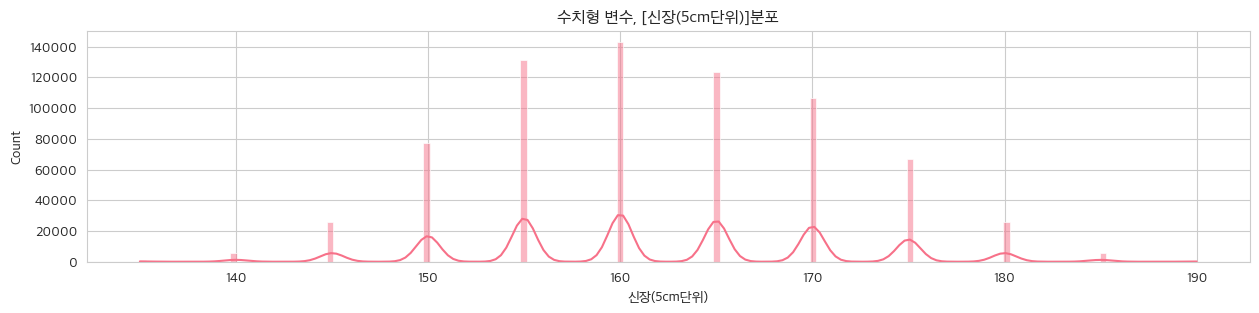

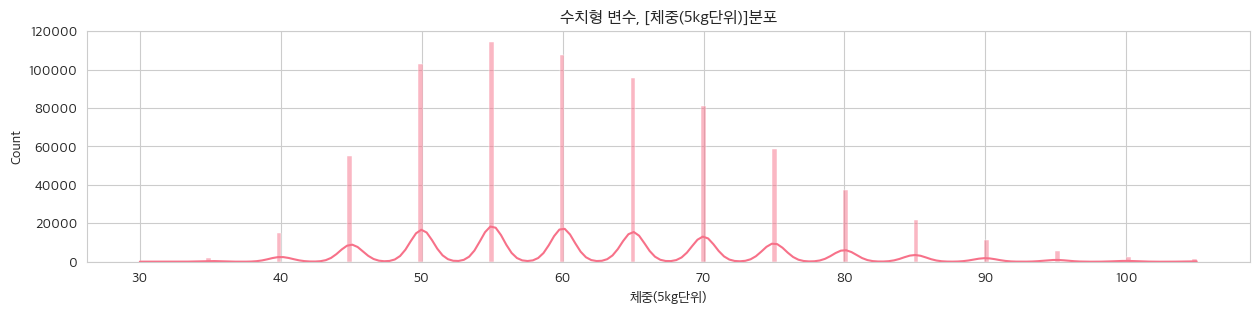

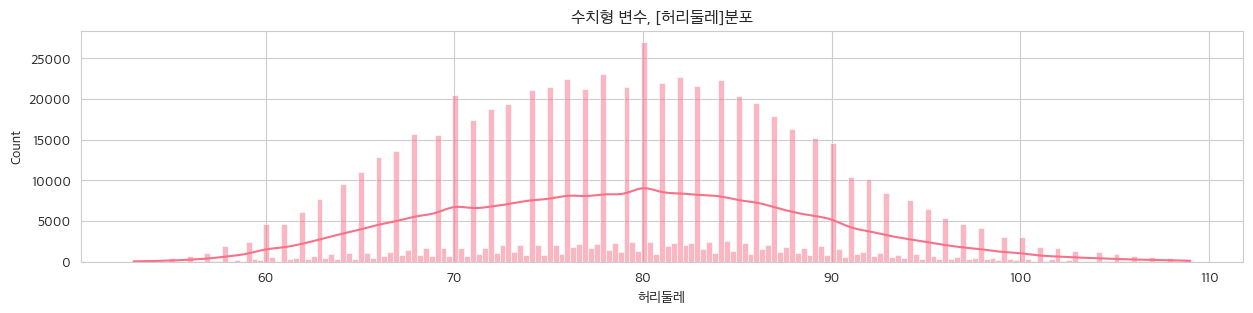

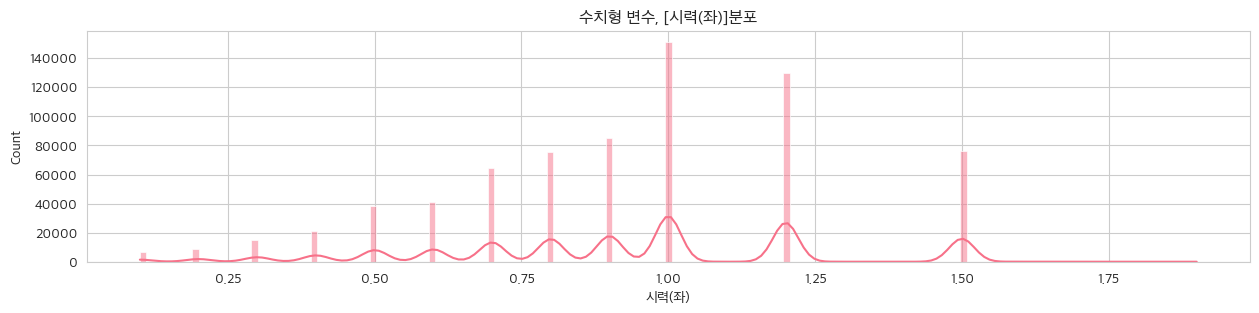

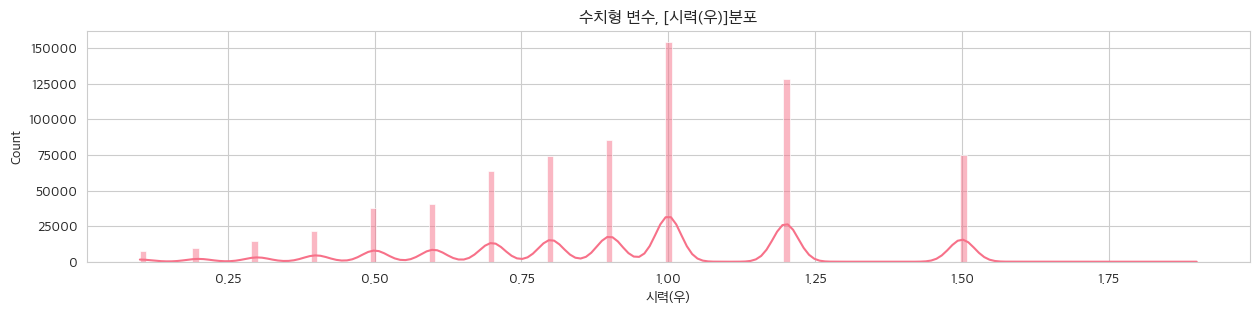

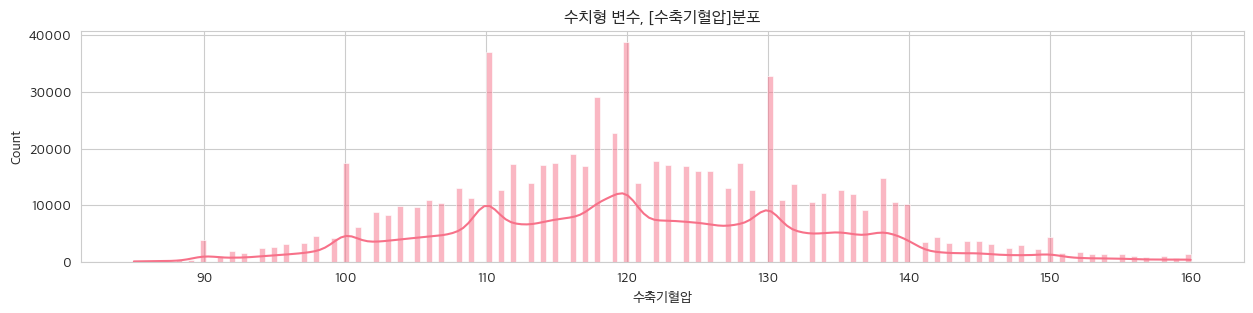

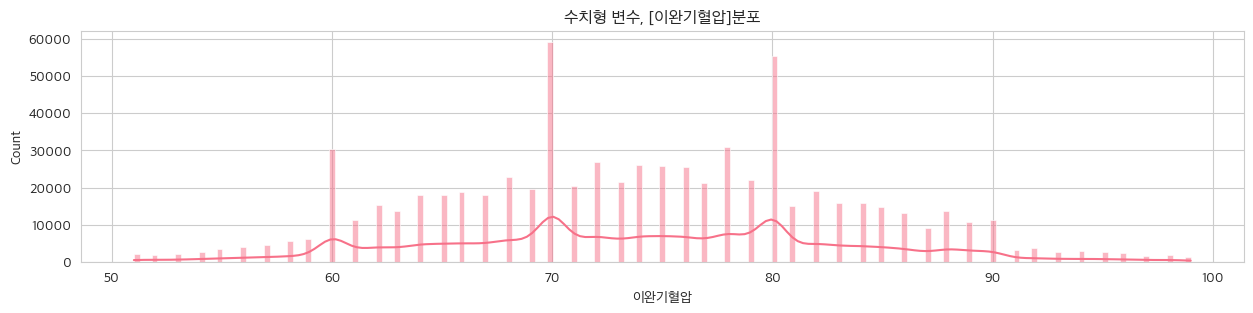

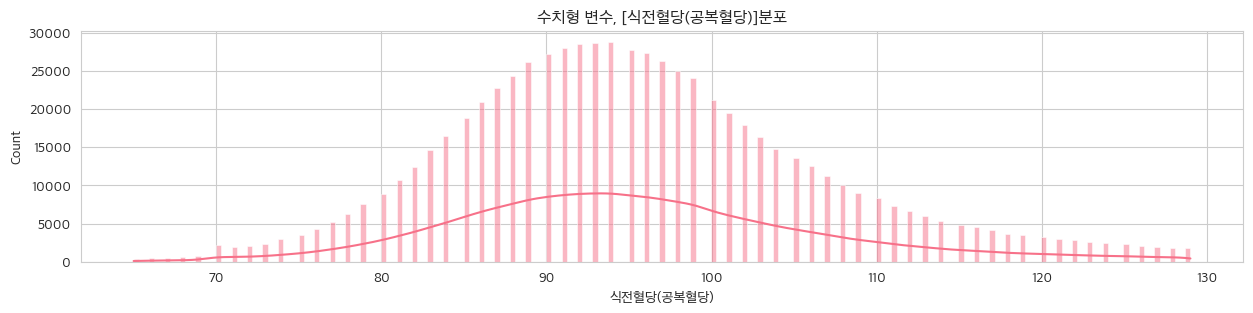

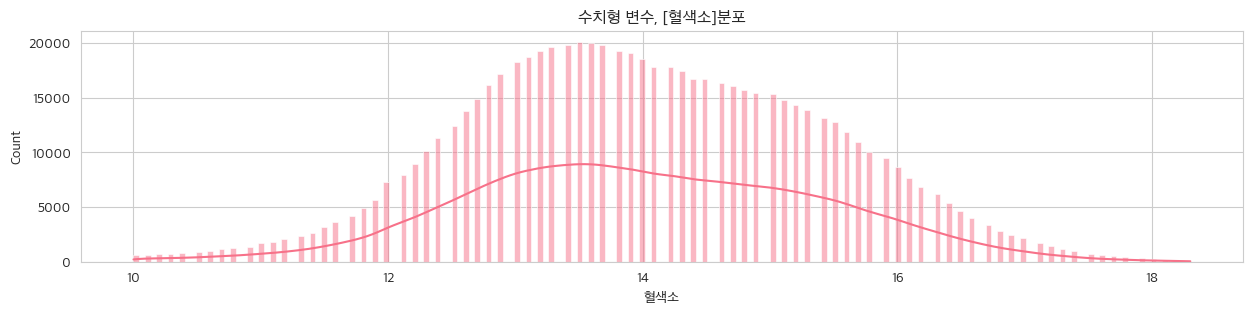

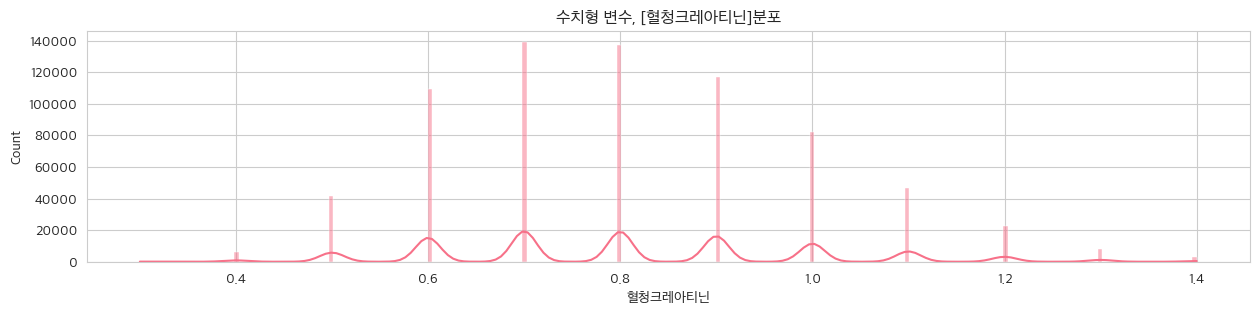

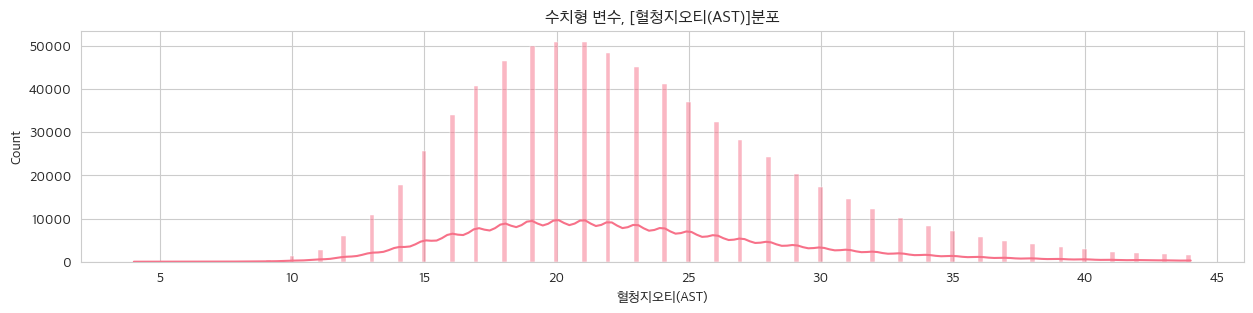

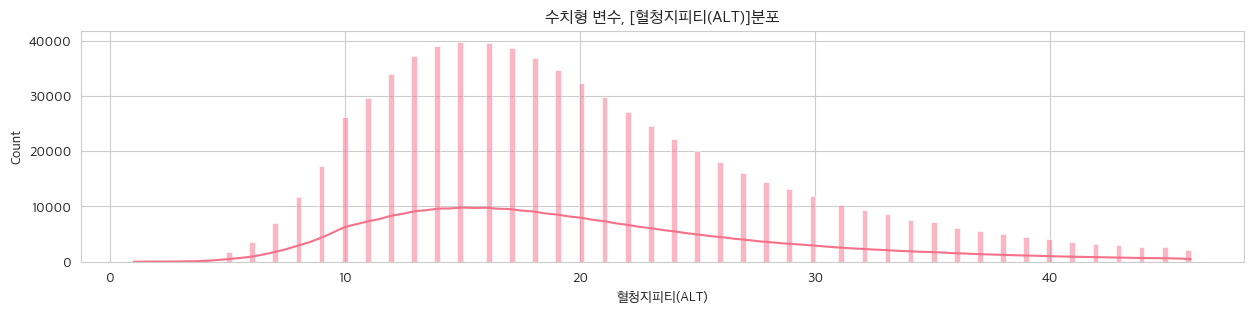

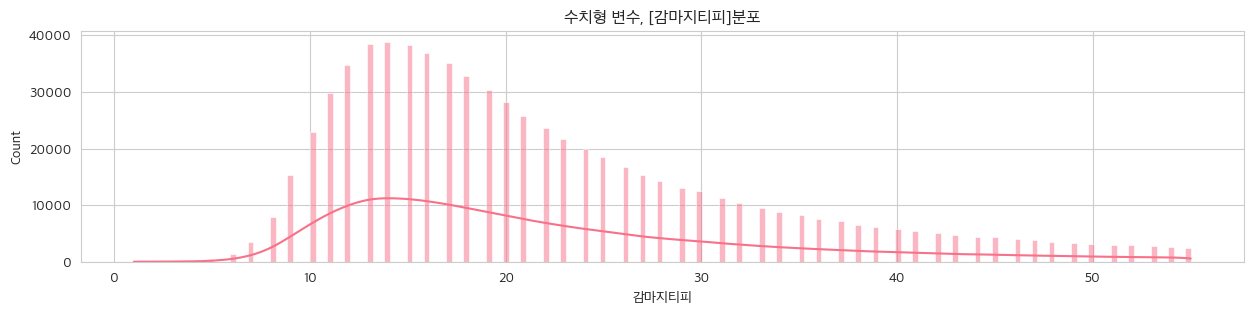

In [ ]:
# 수치형 변수 분포 시각화
for col in new2_df.select_dtypes(include=[int, float]).columns:
    plt.figure(figsize=(15, 3))
    sns.histplot(new2_df[col],kde=True)
    plt.title(f'수치형 변수, [{col}] 분포도')

    plt.show()

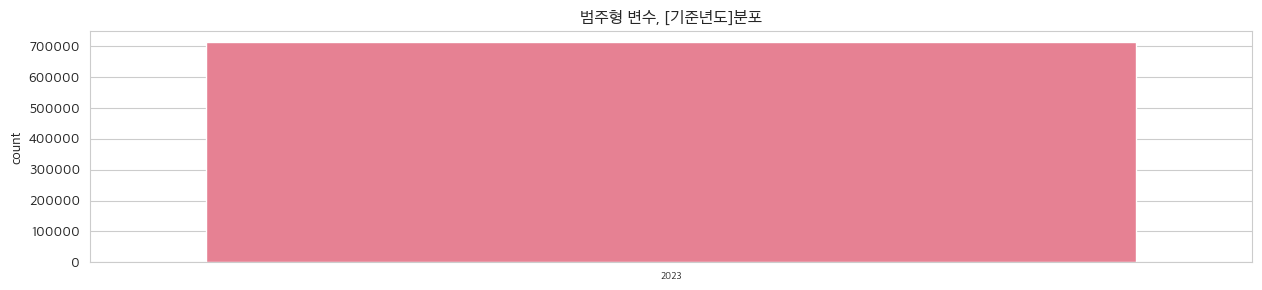

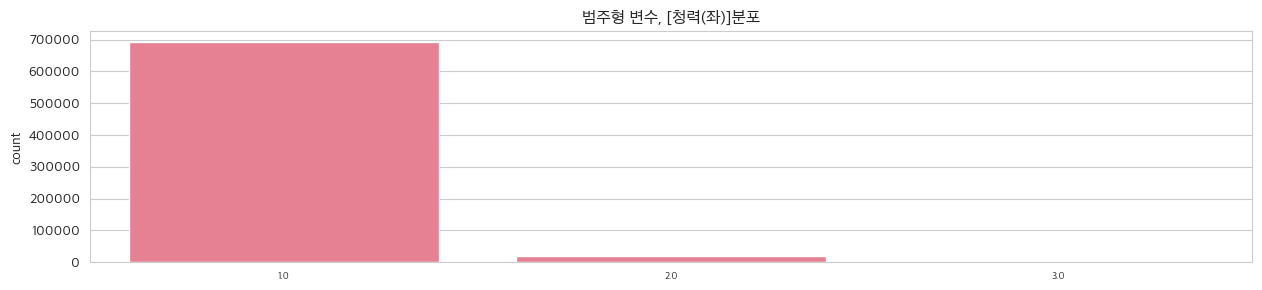

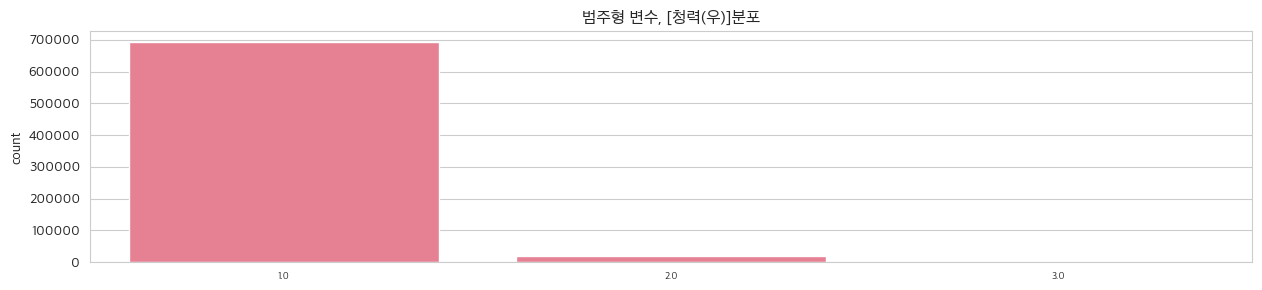

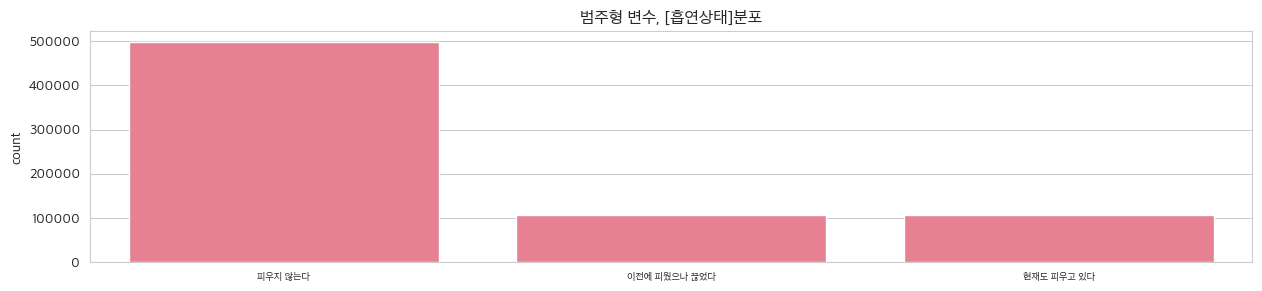

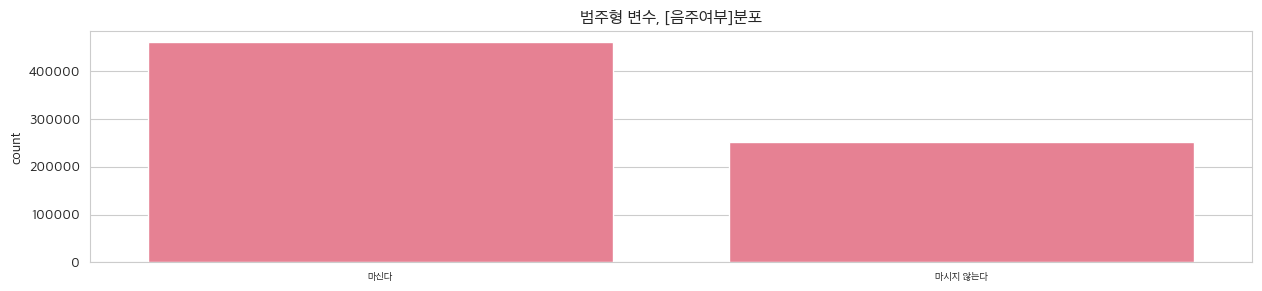

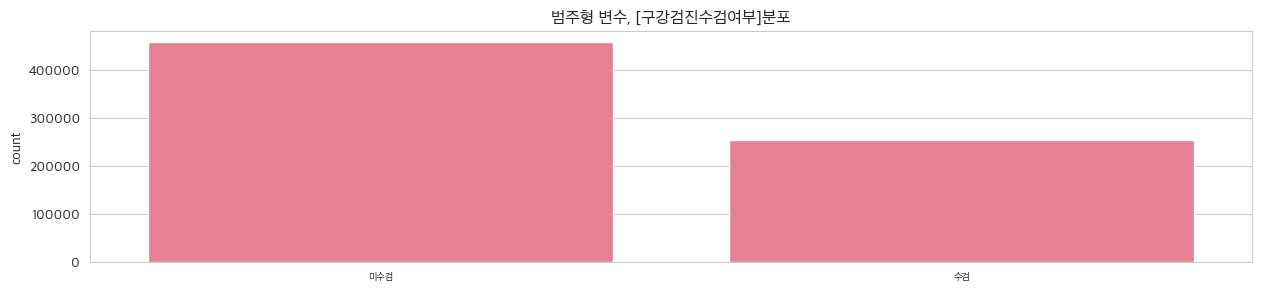

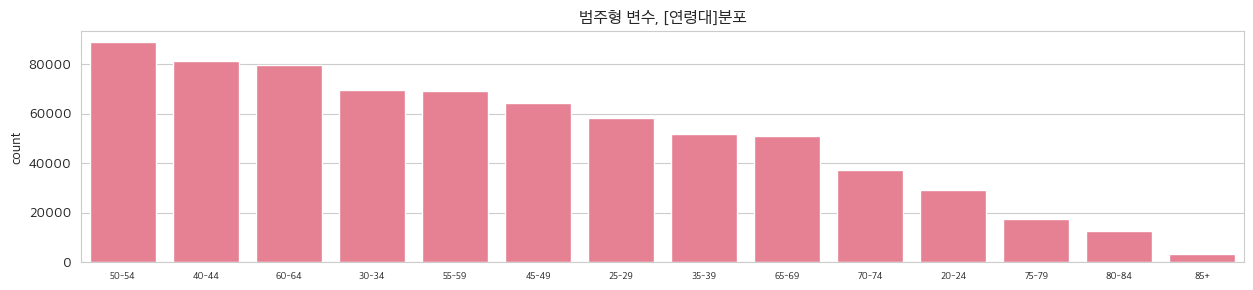

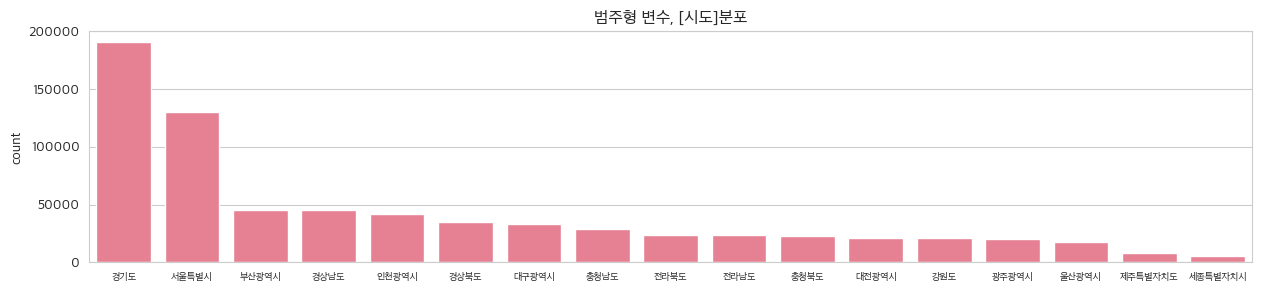

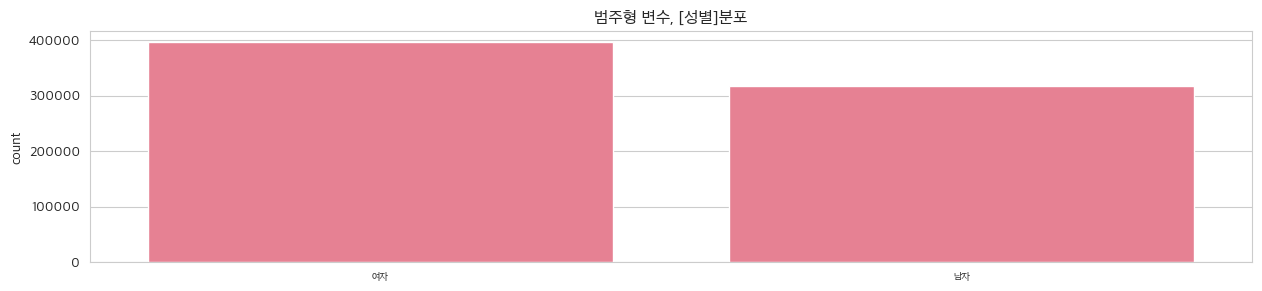

In [ ]:
# 범주형 변수 분포 시각화
for col in new2_df.select_dtypes(include=[object]).columns:
    if col != '가입자일련번호':  # 일련번호 제외
        plt.figure(figsize=(15,3))
        sns.countplot(x=new2_df[col],order=new2_df[col].value_counts().index)
        plt.title(f'범주형 변수, [{col}] 분포도')
        plt.xlabel(None)
        plt.xticks(fontsize=7)

        plt.show()

### 속성 간의 관계 살펴보기

#### 문제12 : 상관관계 분석하기
- 수치형 데이터 간의 상관 관계를 계산하고 히트맵을 사용해 시각화해보세요.

* Correlation Coefficient (상관계수)
상관관계의 정도와 방향을 수치로 나타낸 값
-1에서 1 사이의 값을 가지며, 그 값에 따라 상관의 강도와 방향을 알 수 있다.
.corr()

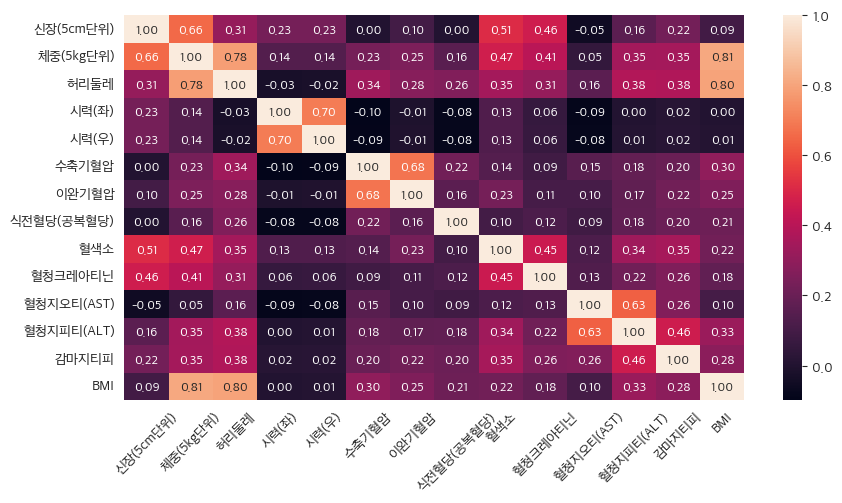

In [ ]:
Correlation = new2_df.select_dtypes(include=[int, float]).corr()

plt.figure(figsize=(10,5))
sns.heatmap(data=Correlation, annot=True, fmt='.2f', annot_kws={"size":9})
plt.xticks(rotation=45)

plt.show()

In [ ]:
# 위 시각화에서 찾을 수 있는 관계성은 어떤 것이 있나요?
# 신장과 체중, 체중과 허리둘레, 시력(좌)와 시력(우), 수축기혈압과 이완기혈압, 식전혈당과 허리둘레,
# 혈색소는 신장, 혈청크레아티닌과 신장, 혈청지피티와 혈청지오티, 감마지티피와 혈청지피티가 높은 관계성을 보인다.

#### 문제13 : 수치형 변수들 간의 산점도 및 각 변수의 히스토그램을 그려 보세요

- 4가지 변수('신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압')에 대한 시각화를 진행해보세요.

<Figure size 1000x1000 with 0 Axes>

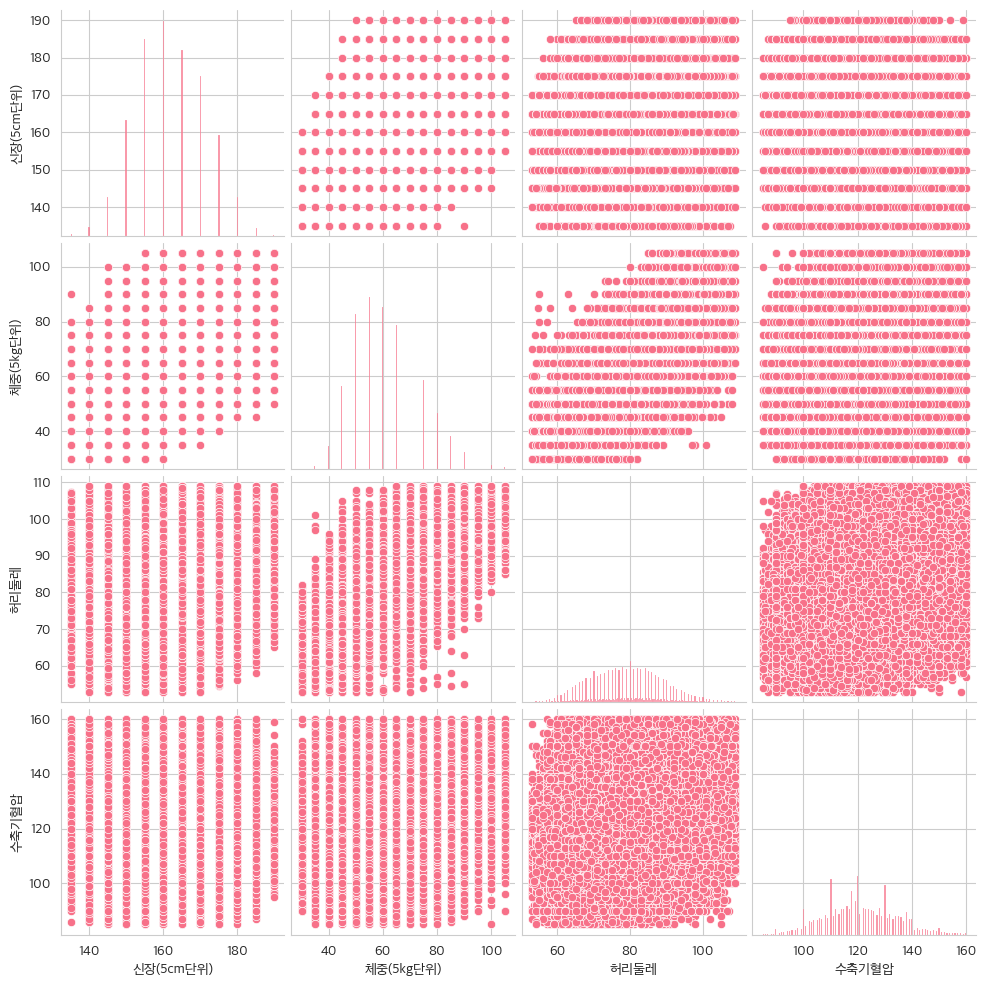

In [ ]:
# 수치형 변수들에 대한 Pair Plot 그리기
four_variables = new2_df[['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압']]

plt.figure(figsize=(10,10))
sns.pairplot(data=four_variables)

plt.show()

#### 문제14 : 성별에 따른 몇 가지 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 기술 통계 비교하기

- 범주형 변수에 따른 수치형 변수의 분포 분석해봅시다. 성별이 주요 건강 지표(신장, 체중, 허리둘레, 수축기혈압)에 어떻게 영향을 미치는지 파악하고 싶습니다.

- 카테고리별 수치형 변수의 기술 통계 분석: 각 카테고리별로 수치형 변수의 평균, 중앙값, 분산 등을 비교합니다.

In [ ]:
new2_df.groupby('성별')[['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압']].describe()

신장(5cm단위)                                                           \
       count        mean       std    min    25%    50%    75%    max   
성별                                                                      
남자  317197.0  169.207606  6.693994  135.0  165.0  170.0  175.0  190.0   
여자  396166.0  156.189224  6.371520  135.0  150.0  155.0  160.0  185.0   

   체중(5kg단위)                                                           허리둘레  \
       count       mean        std   min   25%   50%   75%    max     count   
성별                                                                            
남자  317197.0  69.828261  10.688385  30.0  65.0  70.0  75.0  105.0  317197.0   
여자  396166.0  55.589753   9.370573  30.0  50.0  55.0  60.0  105.0  396166.0   

                                                           수축기혈압              \
         mean       std   min   25%   50%   75%    max     count        mean   
성별                                                                             
남자  83.979991  8.020839  53.0  79.0  84.0  89.0  109.0  317197.0  123.178016   
여자  75.233734  9.164545  53.0  68.5  74.0  81.0  109.0  396166.0  118.931784   

                                                 
          std   min    25%    50%    75%    max  
성별                                               
남자  12.170960  85.0  115.0  122.0  131.0  160.0  
여자  13.819412  85.0  110.0  118.0  129.0  160.0

In [ ]:
new2_df.groupby('성별')[['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압']].agg(['mean', 'median', 'var'])

신장(5cm단위)                    체중(5kg단위)                          허리둘레  \
          mean median        var       mean median         var       mean   
성별                                                                          
남자  169.207606  170.0  44.809552  69.828261   70.0  114.241572  83.979991   
여자  156.189224  155.0  40.596269  55.589753   55.0   87.807631  75.233734   

                           수축기혈압                     
   median        var        mean median         var  
성별                                                   
남자   84.0  64.333863  123.178016  122.0  148.132259  
여자   74.0  83.988881  118.931784  118.0  190.976158

#### 문제15 : 성별에 따른 몇 가지 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 분포를 비교하기

- 성별에 따른 몇 가지 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 분포를 시각화하여 비교해보세요.
- 시각화 방법은 자유롭게 선택하셔도 됩니다.

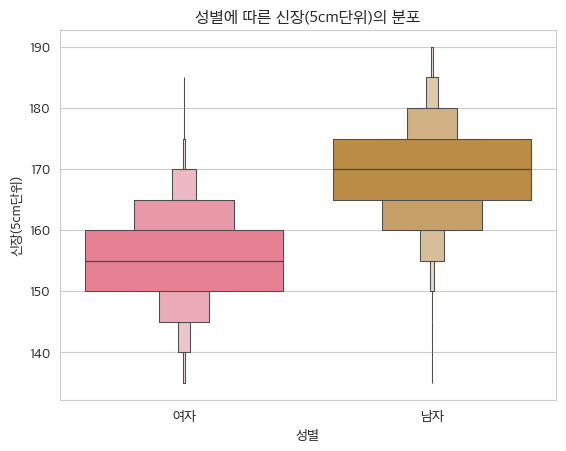

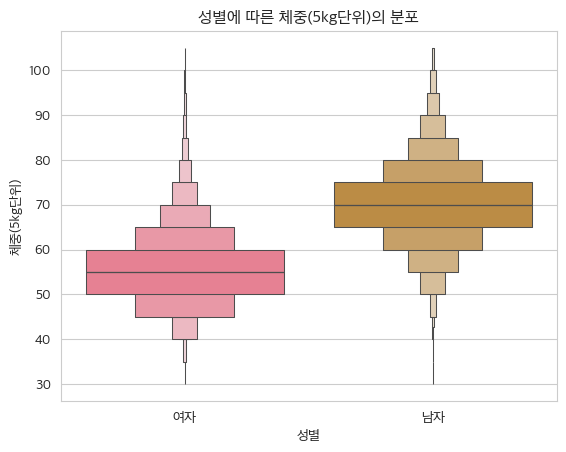

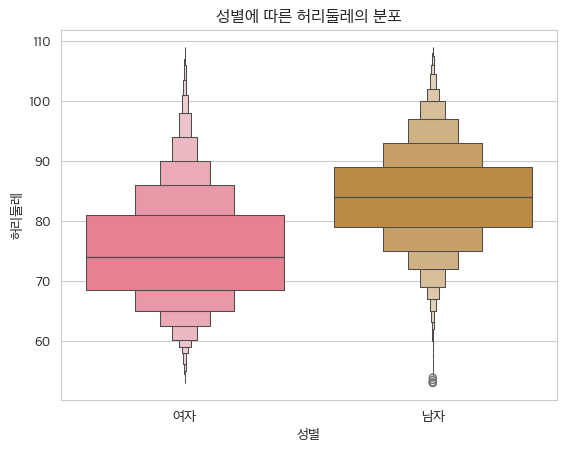

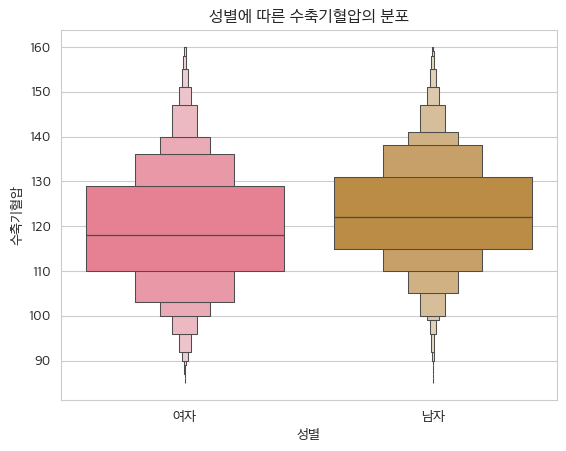

In [ ]:
variable_2 = new2_df[['신장(5cm단위)','체중(5kg단위)','허리둘레','수축기혈압']]

for var in variable_2:
    sns.boxenplot(x="성별", y=var, data=new2_df, hue="성별")
    plt.title(f"성별에 따른 {var}의 분포")

    plt.show()

In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
# 남성의 신장, 체중, 허리둘레, 수축기혈압의 평균이 여성보다 높다

#### 문제16 : 성별에 따른 흡연상태의 비율을 시각화해보세요

In [ ]:
smoking_ratio = new2_df.groupby('성별')['흡연상태'].value_counts(normalize=True, ascending=False).reset_index(name='비율')

# 퍼센트 계산
smoking_ratio['(%)'] = smoking_ratio['비율'].apply(lambda x: f"{x * 100:.1f}%")

# 성별을 인덱스로
smoking_ratio = smoking_ratio.set_index('성별')
smoking_ratio

,흡연상태,비율,(%)
성별,,,
남자,피우지 않는다,0.407838,40.8%
남자,이전에 피웠으나 끊었다,0.298874,29.9%
남자,현재도 피우고 있다,0.293288,29.3%
여자,피우지 않는다,0.930002,93.0%
여자,현재도 피우고 있다,0.036896,3.7%
여자,이전에 피웠으나 끊었다,0.033102,3.3%


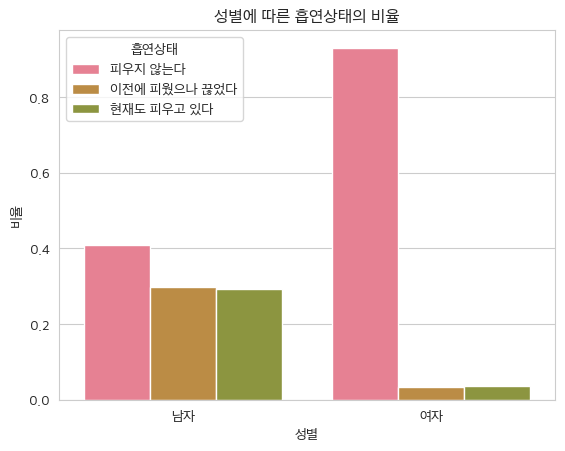

In [ ]:
sns.barplot(x='성별', y='비율', hue='흡연상태', data=smoking_ratio)
plt.title("성별에 따른 흡연상태의 비율")

plt.show()

In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
# 남성의 흡연율이 여성보다 훨씬 높다. 남성은 현재 흡연자와 과거 흡연자가 상대적으로 많다
# 남성중 금연중인 상태가 많다
# 여성의 비흡연 비율이 매우 높고, 현재 흡연자 비율은 거의 없다

#### 문제17 : 연령대별로 주요 건강 지표(신장, 체중, 허리둘레, 수축기혈압)를 분석해보세요.
- 연령대별로 이러한 지표들의 평균 값을 계산하여 피봇테이블을 생성하세요.

In [ ]:
age_var = pd.pivot_table(new2_df, index='연령대', values=variable_2, aggfunc='mean')
age_var

,수축기혈압,신장(5cm단위),체중(5kg단위),허리둘레
연령대,,,,
20-24,114.523046,164.046057,60.453187,73.340064
25-29,115.725727,165.188773,62.792246,75.514771
30-34,116.253852,165.806540,64.461324,77.440608
35-39,117.347757,165.810377,65.356025,78.978501
40-44,118.137895,164.841071,64.179152,78.744345
45-49,119.565186,163.694964,63.490801,78.963559
50-54,120.762288,161.948395,61.979867,78.993064
55-59,122.327328,160.314819,61.028742,79.801886
60-64,124.245970,158.900887,59.954749,80.458891


In [ ]:
# # 위 데이터에서 어떤 인사이트를 확인할 수 있나요?
# 연령대가 높아질수록 수축기혈압은 증가하고, 신장과 체중은 감소하는 경향이 있다
# 허리둘레는 연령대가 높아질수록 조금씩 증가하는 패턴을 보인다

#### 문제18 : 각 지표별로 연령대에 따른 평균값의 변화 추이를 그래프로 시각화해보세요.

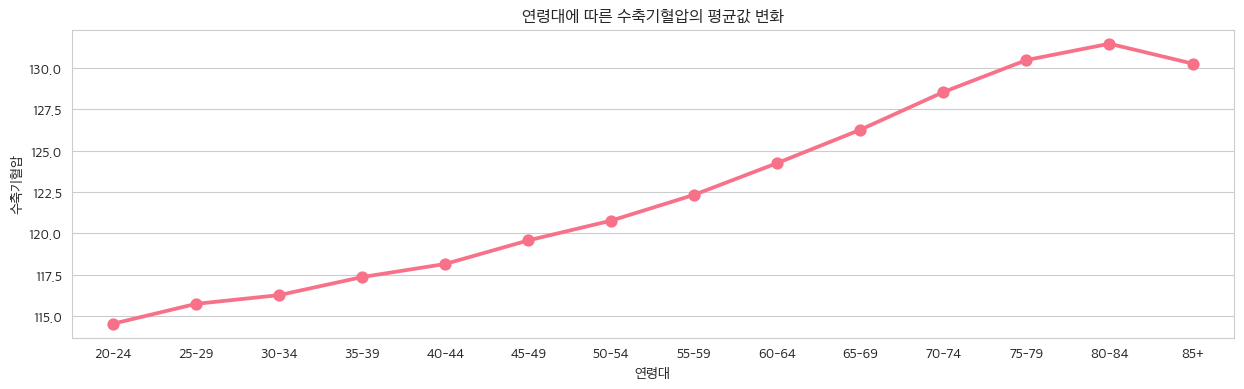

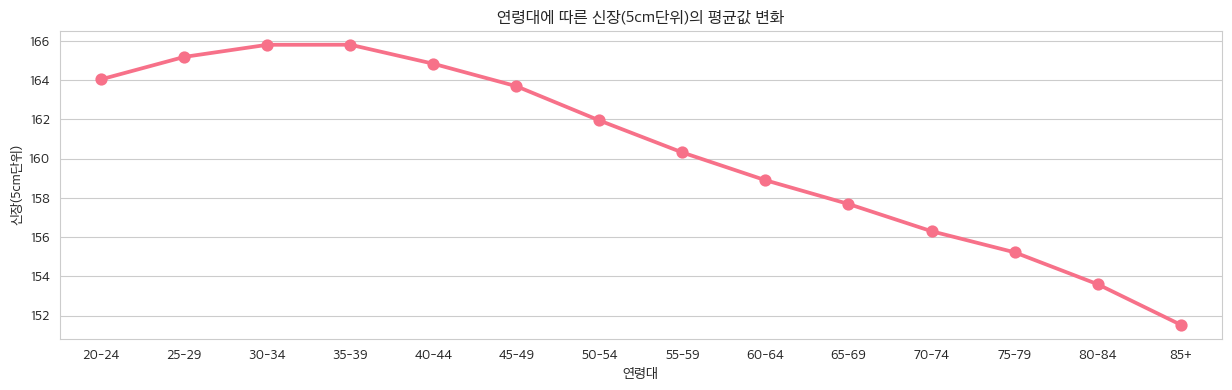

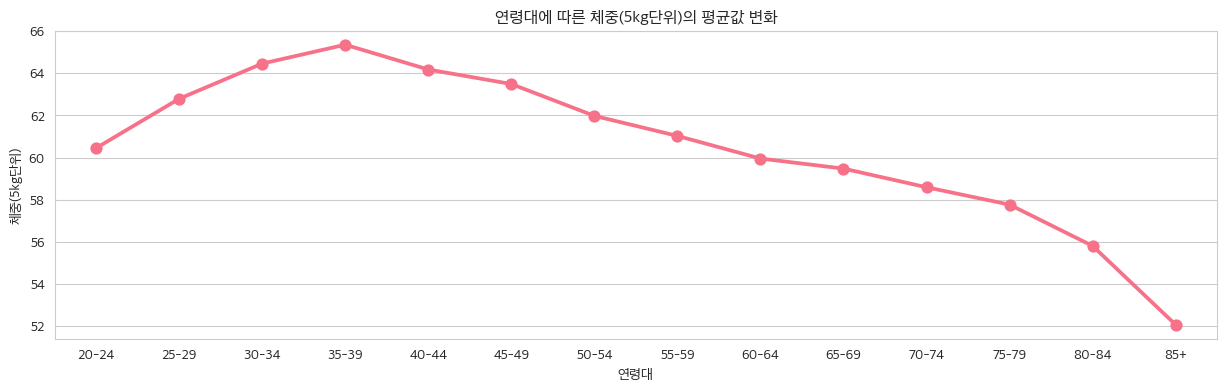

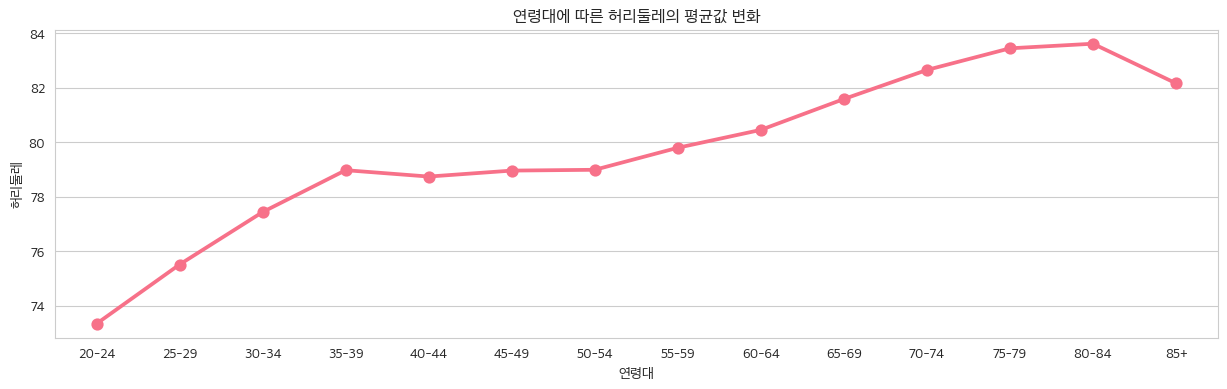

In [ ]:
for col in age_var.columns:
    plt.figure(figsize=(15,4))
    sns.pointplot(x=age_var.index, y=age_var[col])

    plt.title(f"연령대에 따른 {col}의 평균값 변화")
    plt.xlabel("연령대")

    plt.show()

#### 문제19 : BMI를 계산하고, 각 범주별로 분류해부세요.

체질량 지수(BMI)는 개인의 체중(kg)을 신장(m)의 제곱으로 나눈 값으로 계산하며, 비만도를 판단하는 데 널리 사용됩니다. BMI를 계산하여 각 개인의 비만도를 분류해보세요.


$$BMI= \frac{체중(kg)}{신장(m)^2}$$

BMI에 따른 비만도 분류는 다음과 같습니다:

- 저체중: BMI < 18.5
- 정상 체중: 18.5 ≤ BMI < 25
- 과체중: 25 ≤ BMI < 30
- 비만: BMI ≥ 30

세계보건기구(WHO)의 BMI 분류는 다음과 같습니다:

- 저체중: BMI < 18.5
- 정상: 18.5 ≤ BMI < 24.9
- 과체중: 24.9 ≤ BMI < 30
- 비만: BMI ≥ 30

In [ ]:
# BMI에 관한 기초 통계량 계산
def classify_bmi(BMI):
    if BMI >= 30:
        return "비만"

    elif 30 > BMI >= 25:
        return "과체중"

    elif  25 > BMI >= 18.5:
        return "정상체중"

    else:
        return "저체중"

# BMI 계산
new2_df['BMI'] = new2_df['체중(5kg단위)'] / (new2_df['신장(5cm단위)'] / 100) **2

# 비만도 분류
new2_df['비만도'] = new2_df['BMI'].apply(classify_bmi)

# 분류 결과 확인
new2_df[['BMI','비만도']]


,BMI,비만도
0,29.136316,과체중
2,28.888889,과체중
3,27.343750,과체중
4,23.875115,정상체중
5,17.301038,저체중
...,...,...
999993,23.148148,정상체중
999994,21.484375,정상체중
999995,22.491349,정상체중
999998,21.484375,정상체중


#### 문제20 : BMI 대한 기초 통계량을 확인해보세요.

In [ ]:
new2_df['BMI'].describe()

count    713363.000000
mean         23.486363
std           3.526381
min          11.718750
25%          20.811655
50%          23.374726
75%          25.711662
max          49.382716
Name: BMI, dtype: float64

#### 문제21 : BMI에 대한 분포를 더 자세히 살펴보기 위해 히스토그램과 박스 플롯을 사용해 시각화해보세요.

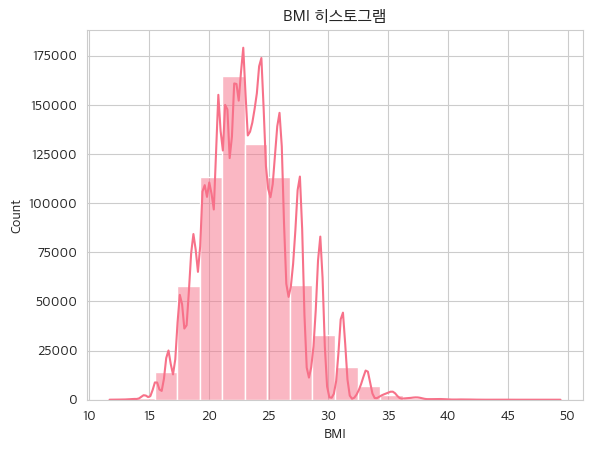

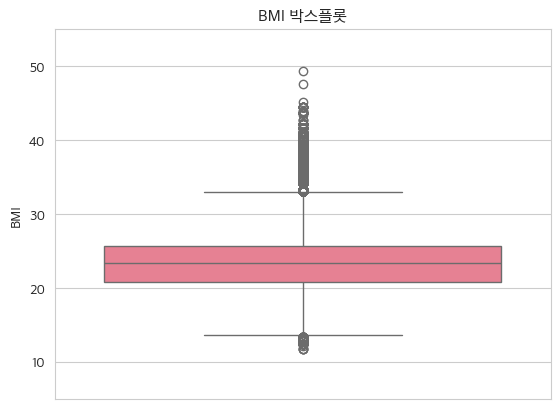

In [ ]:
# 히스토그램
sns.histplot(data=new2_df, x='BMI', kde=True, bins=20,line_kws={'linewidth': 1.5})
plt.title('BMI 히스토그램')
plt.show()

# 박스플롯
sns.boxplot(y=new2_df['BMI'])
plt.title('BMI 박스플롯')
plt.ylim(5, 55)
plt.show()


In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
# 정규분포형태
# 20에서 30사이에 집중되어있다.

#### 문제22 : BMI 범주별 분포를 분석해보세요.
- 위에서 분류한 각 범주별로 인구 분포를 확인해보세요.

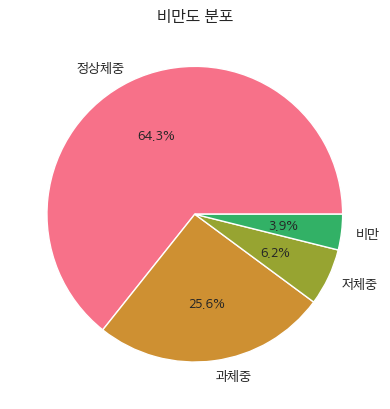

In [ ]:
BMIcounts = new2_df['비만도'].value_counts()

plt.pie(BMIcounts, labels=BMIcounts.index, autopct='%1.1f%%')
plt.title("비만도 분포")

plt.show()

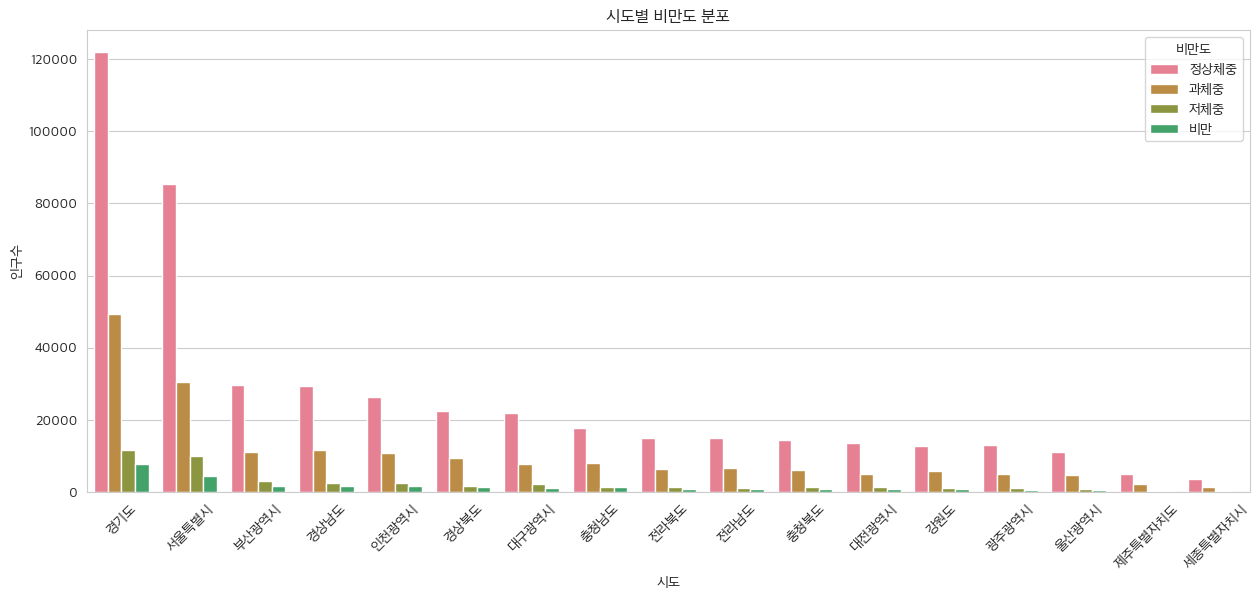

In [ ]:
region_bmi = (new2_df.groupby('시도')['비만도'].value_counts().reset_index(name='개수'))

plt.figure(figsize= (15, 6))
sns.barplot(x='시도', order=new2_df['시도'].value_counts().index, y='개수', hue='비만도', data=region_bmi)

plt.xticks(rotation=45)
plt.title("시도별 비만도 분포")
plt.ylabel("인구수")
plt.xlabel("시도")

plt.show()


In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
# 대부분의 시도에서 정상체중 인구가 가장 많다.
# 경기도와 서울특별시에 과체중과 비만 비율이 높다.

#### 문제23 : 비만도(BMI 범주)와 다른 건강 지표(수축기혈압, 이완기혈압, 식전혈당) 간의 관계를 살펴보세요
- 기술 통계와 시각화를 모두 진행해주세요.

In [ ]:
print("비만도에 따른 건강지표 기술통계 ")
obesity_blood = new2_df.groupby('비만도',observed=True)[['수축기혈압','이완기혈압','식전혈당(공복혈당)']]
obesity_blood.describe()

비만도에 따른 건강지표 기술통계 


수축기혈압                                                           \
         count        mean        std   min    25%    50%    75%    max   
비만도                                                                       
과체중   182379.0  125.112118  12.276459  85.0  117.0  125.0  134.0  160.0   
비만     27766.0  128.071814  12.050397  85.0  120.0  129.0  136.0  160.0   
저체중    44495.0  112.985976  12.579084  85.0  104.0  112.0  120.0  160.0   
정상체중  458723.0  119.434277  13.109116  85.0  110.0  119.0  129.0  160.0   

         이완기혈압                                                    식전혈당(공복혈당)  \
         count       mean       std   min   25%   50%   75%   max      count   
비만도                                                                            
과체중   182379.0  76.576322  8.817356  51.0  70.0  77.0  82.0  99.0   182379.0   
비만     27766.0  78.569077  8.687336  51.0  72.0  80.0  85.0  99.0    27766.0   
저체중    44495.0  69.857130  8.840664  51.0  63.0  70.0  76.0  99.0    44495.0   
정상체중  458723.0  73.051417  9.108046  51.0  67.0  73.0  80.0  99.0   458723.0   

                                                            
           mean        std   min   25%   50%    75%    max  
비만도                                                         
과체중   98.043569  11.296967  65.0  90.0  97.0  105.0  129.0  
비만    99.349060  11.601693  65.0  91.0  98.0  107.0  129.0  
저체중   90.890752   9.929859  65.0  84.0  90.0   96.0  129.0  
정상체중  94.634431  10.828011  65.0  87.0  94.0  101.0  129.0

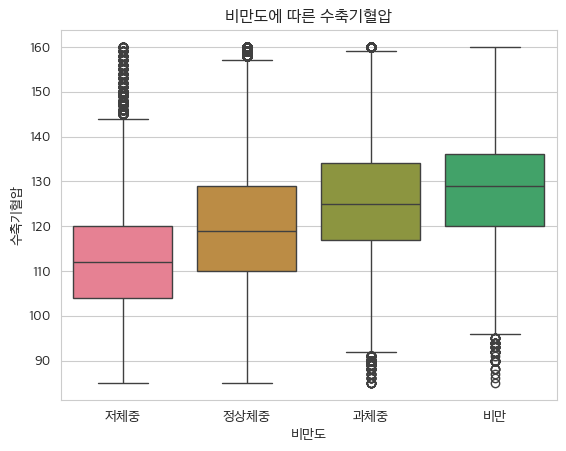

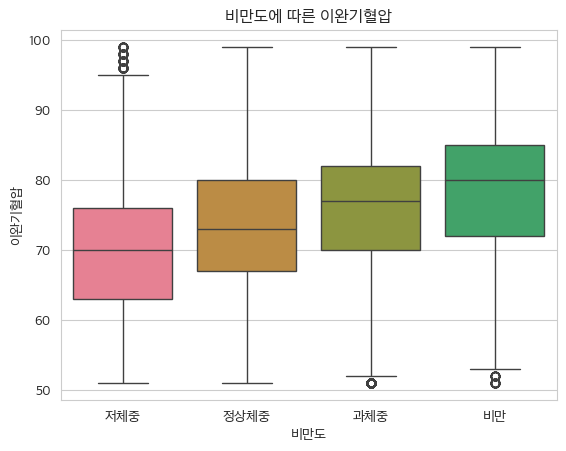

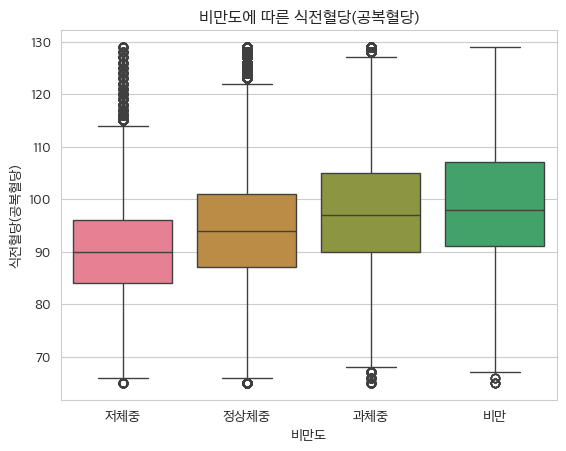

In [ ]:
new2_df['비만도'] = pd.Categorical(new2_df['비만도'],
               ordered=True,
               categories=['저체중', '정상체중', '과체중', '비만'])

for var in ['수축기혈압', '이완기혈압', '식전혈당(공복혈당)']:
    sns.boxplot(x='비만도', y=var, data=new2_df, hue='비만도')
    plt.title(f'비만도에 따른 {var}')
    plt.show()


In [ ]:
# 위 데이터에서 어떤 인사이트를 확인할 수 있나요?
# 비만도가 오를수록 혈압, 혈당이 모두 상승

#### 문제24 : 연령대 및 성별에 따른 BMI 변화를 분석해보세요.
- 연령대가 증가함에 따라 BMI가 어떻게 변화하는지, 그리고 남성과 여성 간의 차이가 있는지를 파악해보세요.
- 데이터를 성별과 연령대 코드로 그룹화하여 각 그룹의 평균 BMI를 계산하고 시각화해보세요.  

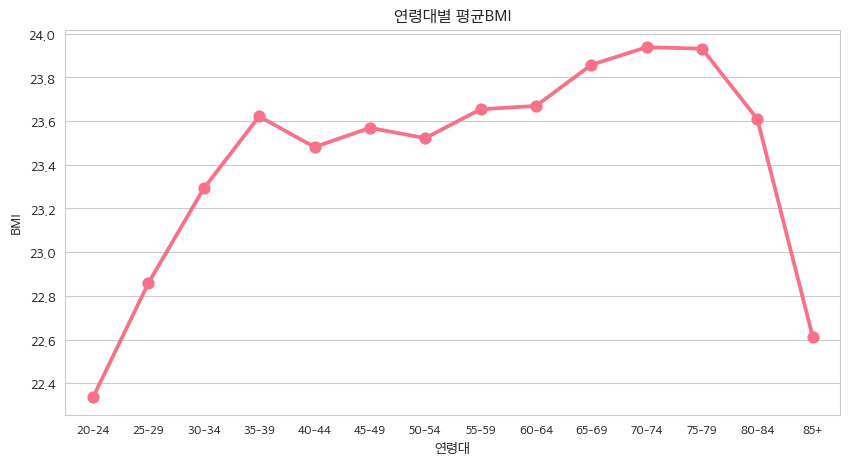

In [ ]:
age_bmi_mean = new2_df.groupby('연령대')['BMI'].mean().reset_index()
gen_bmi_mean = new2_df.groupby('성별')['BMI'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.pointplot(x='연령대',y='BMI',data=age_bmi_mean)
plt.title('연령대별 평균BMI')
plt.xticks(fontsize=9)

plt.show()

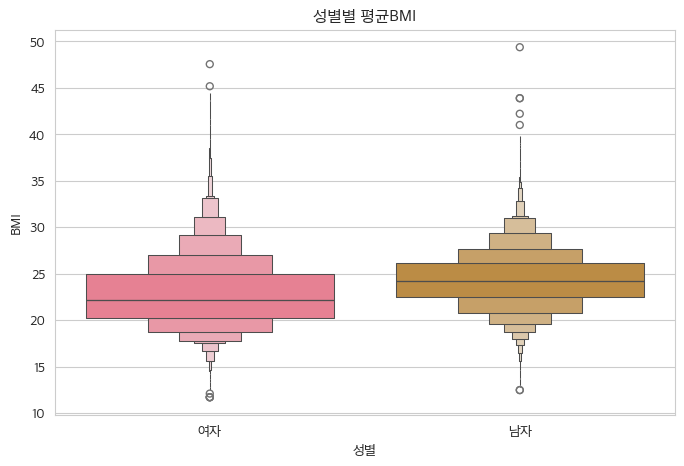

In [ ]:
plt.figure(figsize=(8,5))
sns.boxenplot(x='성별', y='BMI', data=new2_df, hue='성별')
plt.title('성별별 평균BMI')
plt.show()

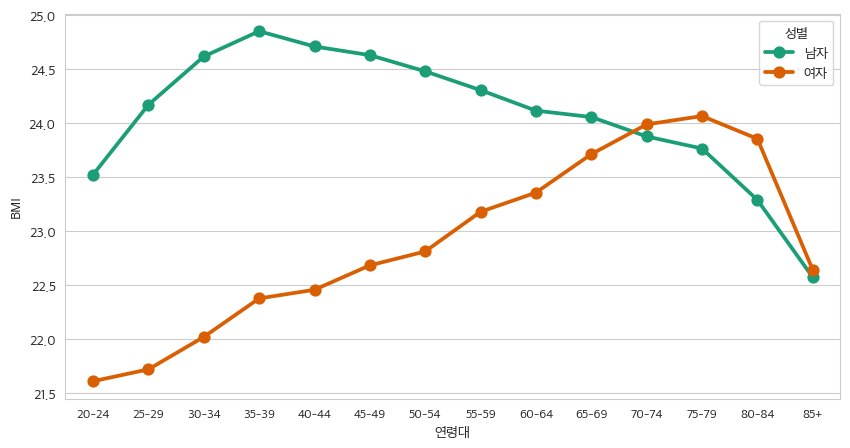

In [ ]:
age_gender_bmi_mean = new2_df.groupby(['연령대', '성별'], observed=True)['BMI'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.pointplot(x='연령대',y='BMI', data=age_gender_bmi_mean, hue='성별', palette='Dark2')
plt.xticks(fontsize=9)

plt.show()


In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
# 나이가 들수록 BMI는 중년까지 증가하다가 고령층에서 감소함
# 남성의 평균 BMI가 여성보다 높지만 고령층에서는 성별 차이가 줄어든다

## 마무리

다양한 통계 및 시각화 분석을 진행하였습니다. 모두들 수고하셨습니다.    
제공된 문제 이외에도 다양한 분석을 진행할 수 있습니다. 마음껏 도전해보세요!